Analisis Readmisiones

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report
import requests # <-- Nueva librería
import zipfile  # <-- Nueva librería
import io       # <-- Nueva librería

# 1. URL del dataset (Readmisiones Diabéticas)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip'


In [7]:
# 2. Descargar el contenido del .zip en memoria
r = requests.get(url)
print("Descarga completa.")

Descarga completa.


In [8]:
# 3. Abrir el .zip desde la memoria
z = zipfile.ZipFile(io.BytesIO(r.content))

In [10]:
df = pd.read_csv(z.open('dataset_diabetes/diabetic_data.csv'), na_values='?')
print("Carga de CSV completa.")

Carga de CSV completa.


C:\Users\PC\AppData\Local\Temp\ipykernel_8544\2371943729.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open('dataset_diabetes/diabetic_data.csv'), na_values='?')


In [11]:
print("--- Vistazo a los Datos (head) ---")
print(df.head())

--- Vistazo a los Datos (head) ---
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...      

In [12]:
print("\n--- Información del DataFrame (info) ---")
df.info()


--- Información del DataFrame (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures   

In [13]:
print("\n--- Conteo de Nulos Reales en 'diag_1' ---")
print(f"Nulos encontrados en 'diag_1': {df['diag_1'].isnull().sum()}")


--- Conteo de Nulos Reales en 'diag_1' ---
Nulos encontrados en 'diag_1': 21


In [16]:
df_clean = df.copy()
# Lista de columnas a eliminar
columnas_a_eliminar = [
    'encounter_id',     # ID
    'patient_nbr',      # ID
    'weight',           # 97% nulos
    'payer_code',       # 40% nulos
    'medical_specialty' # 49% nulos
]

df_clean = df_clean.drop(columns=columnas_a_eliminar)

print(f"Columnas eliminadas. Nueva forma del DataFrame: {df_clean.shape}")

Columnas eliminadas. Nueva forma del DataFrame: (101766, 45)


In [21]:
# (diag_1, diag_2, diag_3, race)
df_clean = df_clean.dropna(subset=['diag_1', 'diag_2', 'diag_3', 'race'])

print(f"Filas con nulos eliminadas. Nueva forma del DataFrame: {df_clean.shape}")

# ¡Revisemos que TODOS los nulos hayan desaparecido!
print("\n--- Conteo total de nulos restantes ---")
print(df_clean.isnull().sum().sum())

Filas con nulos eliminadas. Nueva forma del DataFrame: (98053, 45)

--- Conteo total de nulos restantes ---
174705


In [22]:
#Calcular el total de nulos por columna en nuestro dataframe limpio
nulos_restantes = df_clean.isnull().sum()

#Filtrar para ver solo las columnas que AÚN TIENEN nulos (más de 0)
columnas_con_nulos = nulos_restantes[nulos_restantes > 0].sort_values(ascending=False)

#Imprimir nuestra "lista de culpables"
print("--- Columnas que TODAVÍA tienen nulos: ---")
print(columnas_con_nulos)

--- Columnas que TODAVÍA tienen nulos: ---
max_glu_serum    92845
A1Cresult        81860
dtype: int64


In [23]:
#Rellenar los nulos en las columnas de pruebas con 'None'
df_clean['max_glu_serum'] = df_clean['max_glu_serum'].fillna('None')
df_clean['A1Cresult'] = df_clean['A1Cresult'].fillna('None')

print("Nulos de 'max_glu_serum' y 'A1Cresult' rellenados con 'None'.")

# -LA VERIFICACIÓN FINAL! -
#Ahora sí, el conteo total de nulos debe ser CERO.
print("\n--- Conteo total de nulos restantes ---")
print(df_clean.isnull().sum().sum())

#Vamos a verificar una de las columnas
print("\n--- Nuevos valores en 'A1Cresult' ---")
print(df_clean['A1Cresult'].value_counts())

Nulos de 'max_glu_serum' y 'A1Cresult' rellenados con 'None'.

--- Conteo total de nulos restantes ---
0

--- Nuevos valores en 'A1Cresult' ---
A1Cresult
None    81860
>8       7631
Norm     4854
>7       3708
Name: count, dtype: int64


In [24]:
#Vamos a ver los valores de nuestra columna objetivo
print("--- Valores Originales en 'readmitted' ---")
print(df_clean['readmitted'].value_counts())

#Crear nuestra nueva columna 'y' (el objetivo)
# 1 si es '<30', 0 en cualquier otro caso
df_clean['y_objetivo'] = df_clean['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

#Eliminar la columna 'readmitted' original
df_clean = df_clean.drop(columns=['readmitted'])

# La verificación
print("\n--- Nuevos Valores en 'y_objetivo' ---")
# Esto nos mostrará cuántos "éxitos" (0) vs "fallos" (1) tenemos.
print(df_clean['y_objetivo'].value_counts())

--- Valores Originales en 'readmitted' ---
readmitted
NO     52338
>30    34649
<30    11066
Name: count, dtype: int64

--- Nuevos Valores en 'y_objetivo' ---
y_objetivo
0    86987
1    11066
Name: count, dtype: int64


In [25]:
# Separar las features (X) del objetivo (y)
X = df_clean.drop(columns=['y_objetivo'])
y = df_clean['y_objetivo']

# Guardar los nombres de las columnas de texto (categóricas)
columnas_categoricas = X.select_dtypes(include=['object']).columns

print(f"Encontradas {len(columnas_categoricas)} columnas de texto para codificar.")

# Aplicar One-Hot Encoding
# Esto convertirá todas las columnas de texto en columnas numéricas (0s y 1s)
X_codificado = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

print("¡Codificación completada!")

# Verificación
print("\n--- Nueva Información de 'X_codificado' (solo números) ---")
# Deberíamos tener MUCHAS más columnas ahora, pero todas numéricas.
X_codificado.info()

print("\n--- Vistazo a las nuevas columnas ---")
print(X_codificado.head())

Encontradas 33 columnas de texto para codificar.
¡Codificación completada!

--- Nueva Información de 'X_codificado' (solo números) ---
<class 'pandas.core.frame.DataFrame'>
Index: 98053 entries, 1 to 101765
Columns: 2317 entries, admission_type_id to diabetesMed_Yes
dtypes: bool(2306), int64(11)
memory usage: 224.6 MB

--- Vistazo a las nuevas columnas ---
   admission_type_id  discharge_disposition_id  admission_source_id  \
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   
5                  2                         1                    2   

   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
1                 3                  59               0               18   
2                 2                  11               5       

In [26]:
# Separar las features (X) del objetivo (y)
# (Volvemos a empezar desde df_clean)
X = df_clean.drop(columns=['y_objetivo'])
y = df_clean['y_objetivo']

# Identificar las columnas que SÍ son numéricas reales (continuas)
# Estas son las únicas que queremos que sigan siendo números.
columnas_numericas_reales = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

# Identificar las columnas categóricas (¡todas las demás!)
# Esto incluirá las de texto (object) Y las de IDs (int)
todas_las_columnas = X.columns
columnas_categoricas = [col for col in todas_las_columnas if col not in columnas_numericas_reales]

print(f"Columnas numéricas reales identificadas: {len(columnas_numericas_reales)}")
print(f"Columnas categóricas identificadas: {len(columnas_categoricas)}") # Deberían ser 38

# ¡Aplicar One-Hot Encoding a las 38 columnas categóricas!
# drop_first=True es clave para reducir la dimensionalidad
X_codificado = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

print("¡Codificación (correcta) completada!")

# Verificación
print("\n--- Nueva Información de 'X_codificado' (solo números) ---")
# Ahora debería tener 7 columnas 'int'/'float' y el resto 'bool'
X_codificado.info()

print(f"\nForma final de X: {X_codificado.shape}")

Columnas numéricas reales identificadas: 7
Columnas categóricas identificadas: 37
¡Codificación (correcta) completada!

--- Nueva Información de 'X_codificado' (solo números) ---
<class 'pandas.core.frame.DataFrame'>
Index: 98053 entries, 1 to 101765
Columns: 2374 entries, time_in_hospital to diabetesMed_Yes
dtypes: bool(2367), int64(7)
memory usage: 227.3 MB

Forma final de X: (98053, 2374)


Escalado de datos

In [27]:
from sklearn.preprocessing import StandardScaler

# DIVIDIR LOS DATOS
# 80% para entrenamiento, 20% para prueba
# Usamos 'stratify=y' para asegurar que el desbalanceo 8:1
# se mantenga igual en ambos sets (¡muy importante!)
X_train, X_test, y_train, y_test = train_test_split(
    X_codificado, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

print(f"Datos divididos. {len(X_train)} filas de entrenamiento, {len(X_test)} filas de prueba.")

# IDENTIFICAR LAS 7 COLUMNAS A ESCALAR
# Reusamos la lista de antes (¡solo escalamos las 7 numéricas!)
columnas_numericas_reales = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

# CREAR Y AJUSTAR EL ESCALADOR
scaler = StandardScaler()

# Ajustamos (fit) el scaler SOLO con los datos de X_train
scaler.fit(X_train[columnas_numericas_reales])

# APLICAR EL ESCALADO (transform)
# Aplicamos la transformación a AMBOS sets (train y test)
X_train[columnas_numericas_reales] = scaler.transform(X_train[columnas_numericas_reales])
X_test[columnas_numericas_reales] = scaler.transform(X_test[columnas_numericas_reales])

print("¡Datos escalados con éxito!")

# Verificación
print("\n--- Vistazo a X_train después de escalar ---")
print(X_train[columnas_numericas_reales].head())

Datos divididos. 78442 filas de entrenamiento, 19611 filas de prueba.
¡Datos escalados con éxito!

--- Vistazo a X_train después de escalar ---
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
66693         -0.475088           -0.207566       -0.788930        -0.629607   
80539         -1.143361           -0.816240       -0.788930        -0.752427   
40540         -1.143361            0.046048       -0.788930        -0.383969   
49767          1.863865            1.161949        2.131646         1.949595   
49265          0.861457           -0.562626        0.963416         2.932148   

       number_outpatient  number_emergency  number_inpatient  
66693          -0.294202         -0.215616          2.644742  
80539          -0.294202         -0.215616         -0.509962  
40540          -0.294202         -0.215616          0.278714  
49767          -0.294202         -0.215616         -0.509962  
49265          -0.294202         -0.215616         -0.509962

A modelar

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- 1. Modelo de Regresión Logística ---
# solver='saga' es bueno para datasets grandes
# class_weight='balanced' es la clave para nuestro desbalanceo
print("Entrenando Regresión Logística...")
log_model = LogisticRegression(class_weight='balanced', solver='saga', random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)
print("¡Regresión Logística entrenada!")

# --- 2. Modelo de Random Forest ---
# n_estimators=100 significa 100 "árboles"
# class_weight='balanced' es la clave
# n_jobs=-1 usa todos los procesadores de tu PC para ir más rápido
print("\nEntrenando Random Forest (puede tardar unos minutos)...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("¡Random Forest entrenado!")

# --- 3. Hacer predicciones en el set de prueba ---
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("\n¡Predicciones generadas en el set de prueba!")

Entrenando Regresión Logística...


d:\Ciencia de Datos\Proyecto_Readmisiones\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


¡Regresión Logística entrenada!

Entrenando Random Forest (puede tardar unos minutos)...
¡Random Forest entrenado!

¡Predicciones generadas en el set de prueba!


--- Evaluación del Modelo de Regresión Logística ---
                precision    recall  f1-score   support

 No Readmitido       0.92      0.67      0.78     17398
Readmitido <30       0.18      0.56      0.27      2213

      accuracy                           0.66     19611
     macro avg       0.55      0.62      0.52     19611
  weighted avg       0.84      0.66      0.72     19611


--- Evaluación del Modelo Random Forest ---
                precision    recall  f1-score   support

 No Readmitido       0.89      1.00      0.94     17398
Readmitido <30       0.71      0.00      0.01      2213

      accuracy                           0.89     19611
     macro avg       0.80      0.50      0.47     19611
  weighted avg       0.87      0.89      0.84     19611


--- Matriz de Confusión (Random Forest) ---


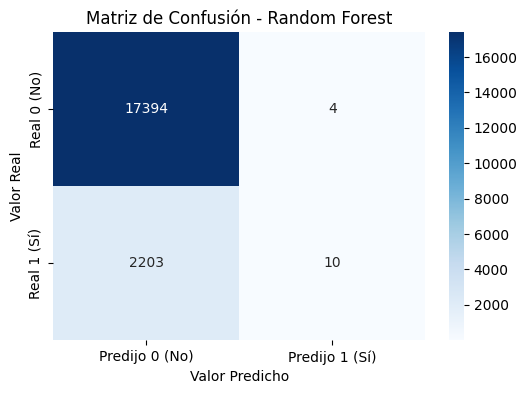

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. Evaluación de Regresión Logística ---
print("--- Evaluación del Modelo de Regresión Logística ---")
# Usamos target_names para que el reporte sea fácil de leer
print(classification_report(y_test, y_pred_log, target_names=['No Readmitido', 'Readmitido <30']))

# --- 2. Evaluación de Random Forest ---
print("\n--- Evaluación del Modelo Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['No Readmitido', 'Readmitido <30']))

# --- 3. Visualizar la Matriz de Confusión del MEJOR modelo ---
# (Casi seguro será el Random Forest)
print("\n--- Matriz de Confusión (Random Forest) ---")
cm = confusion_matrix(y_test, y_pred_rf)

# Graficar la matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Predijo 0 (No)', 'Predijo 1 (Sí)'], 
            yticklabels=['Real 0 (No)', 'Real 1 (Sí)'])
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [30]:
# 1. Obtener las "importancias" del modelo Random Forest
# A pesar de que el modelo falló en la predicción, 
# sí nos puede decir qué features consideró importantes.
importances = rf_model.feature_importances_
feature_names = X_codificado.columns # Los nombres de las 2,374 columnas

# 2. Crear un DataFrame para verlas
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False) # Ordenar de mayor a menor

# 3. Mostrar las 30 características MÁS importantes
print("--- TOP 30 CARACTERÍSTICAS MÁS IMPORTANTES ---")
top_30_features = feature_importance_df.head(30)
print(top_30_features)

# 4. Guardar los nombres de estas 30 features en una lista
list_top_30_features = top_30_features['Feature'].tolist()

--- TOP 30 CARACTERÍSTICAS MÁS IMPORTANTES ---
                          Feature  Importance
1              num_lab_procedures    0.050954
3                 num_medications    0.047723
6                number_inpatient    0.039375
0                time_in_hospital    0.038300
2                  num_procedures    0.026957
11                    gender_Male    0.014463
4               number_outpatient    0.013581
5                number_emergency    0.012753
8                  race_Caucasian    0.011283
59          admission_source_id_7    0.011133
19                    age_[70-80)    0.011133
18                    age_[60-70)    0.010528
2311           number_diagnoses_9    0.009634
22            admission_type_id_2    0.009613
2372                    change_No    0.009401
2364               insulin_Steady    0.009206
20                    age_[80-90)    0.008943
2363                   insulin_No    0.008235
30     discharge_disposition_id_3    0.008166
2323               A1Cresult_None

In [31]:
# 1. Obtener la lista de las 30 mejores features (ya la tienes en 'list_top_30_features')
# (Si la celda anterior se desconectó, solo necesitas volver a correr la última línea de esa celda)
# list_top_30_features = top_30_features['Feature'].tolist()

print(f"Entrenando un nuevo modelo usando SOLO {len(list_top_30_features)} características...")

# 2. Crear los nuevos DataFrames "Top 30"
# Seleccionamos solo las 30 columnas de nuestros sets de entrenamiento y prueba
X_train_top30 = X_train[list_top_30_features]
X_test_top30 = X_test[list_top_30_features]

# --- 3. Entrenar el NUEVO Random Forest ---
# Usamos la misma configuración (class_weight='balanced')
print("Entrenando Random Forest (Top 30)...")
rf_model_top30 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model_top30.fit(X_train_top30, y_train)
print("¡Nuevo modelo (Top 30) entrenado!")

# --- 4. Hacer predicciones con el nuevo modelo ---
y_pred_rf_top30 = rf_model_top30.predict(X_test_top30)
print("¡Nuevas predicciones generadas!")

Entrenando un nuevo modelo usando SOLO 30 características...
Entrenando Random Forest (Top 30)...
¡Nuevo modelo (Top 30) entrenado!
¡Nuevas predicciones generadas!


--- Evaluación del Modelo Random Forest (Top 30) ---
                precision    recall  f1-score   support

 No Readmitido       0.89      1.00      0.94     17398
Readmitido <30       0.41      0.01      0.02      2213

      accuracy                           0.89     19611
     macro avg       0.65      0.50      0.48     19611
  weighted avg       0.83      0.89      0.84     19611


--- Matriz de Confusión (Random Forest - Top 30) ---


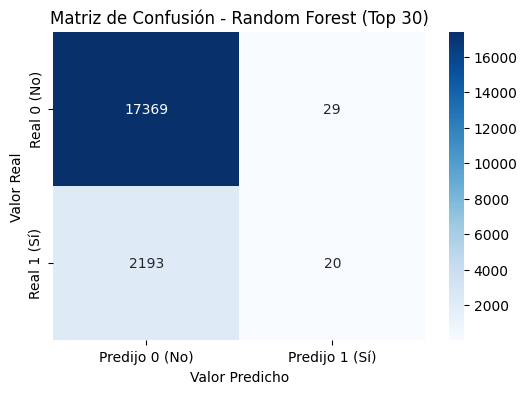

In [32]:
# --- 1. Evaluación del NUEVO Random Forest (Top 30) ---
print("--- Evaluación del Modelo Random Forest (Top 30) ---")
print(classification_report(y_test, y_pred_rf_top30, target_names=['No Readmitido', 'Readmitido <30']))

# --- 2. Visualizar la NUEVA Matriz de Confusión ---
print("\n--- Matriz de Confusión (Random Forest - Top 30) ---")
cm_top30 = confusion_matrix(y_test, y_pred_rf_top30)

# Graficar la matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm_top30, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Predijo 0 (No)', 'Predijo 1 (Sí)'], 
            yticklabels=['Real 0 (No)', 'Real 1 (Sí)'])
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.title('Matriz de Confusión - Random Forest (Top 30)')
plt.show()

In [33]:
import joblib

# 1. Guardar el Modelo (El "cerebro")
# (Asumiendo que tu modelo se llama 'log_model')
joblib.dump(log_model, 'modelo_readmision_logistica.joblib')

# 2. Guardar el Escalador (El "transformador" numérico)
# (Asumiendo que tu escalador se llama 'scaler')
joblib.dump(scaler, 'scaler_readmision.joblib')

# 3. Guardar la Plantilla de Columnas (El "molde")
# (Asumiendo que tu DataFrame codificado se llama 'X_codificado')
list_of_all_columns = X_codificado.columns.tolist()
joblib.dump(list_of_all_columns, 'columnas_modelo_readmision.joblib')

print("¡Éxito! Se han guardado 3 artefactos:")
print("1. modelo_readmision_logistica.joblib")
print("2. scaler_readmision.joblib")
print("3. columnas_modelo_readmision.joblib")

¡Éxito! Se han guardado 3 artefactos:
1. modelo_readmision_logistica.joblib
2. scaler_readmision.joblib
3. columnas_modelo_readmision.joblib
